In [413]:
import pandas as pd
import matplotlib.pyplot as pplot
import seaborn as sborn

In [414]:
data = pd.read_csv('archive/student-mat.csv')
see_cols = data.columns

In [415]:
'''
FEATURE SELECTIONS
NUMERICAL
[ "G1", "G2" ]

["absences", "Walc", "Dalc", "health", "goout", "failures", "studytime", "freetime" ]

CATEGORICAL
[ "activities", "internet", "romantic" ]
'''

'\nFEATURE SELECTIONS\nNUMERICAL\n[ "G1", "G2" ]\n\n["absences", "Walc", "Dalc", "health", "goout", "failures", "studytime", "freetime" ]\n\nCATEGORICAL\n[ "activities", "internet", "romantic" ]\n'

In [416]:
missing_values = data.isnull().sum()
print(missing_values)

school        0
sex           0
age           0
address       0
famsize       0
Pstatus       0
Medu          0
Fedu          0
Mjob          0
Fjob          0
reason        0
guardian      0
traveltime    0
studytime     0
failures      0
schoolsup     0
famsup        0
paid          0
activities    0
nursery       0
higher        0
internet      0
romantic      0
famrel        0
freetime      0
goout         0
Dalc          0
Walc          0
health        0
absences      0
G1            0
G2            0
G3            0
dtype: int64


In [417]:
data = data[(data['G3'] >= 0) & (data['G3'] <= 20)]

def remove_outliers(data, col):
    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)
    IQR = Q3 - Q1
    return data[(data[col] >= Q1 - 1.5 * IQR) & (data[col] <= Q3 + 1.5 * IQR)]

for col in ['G1', 'G2', 'G3']:
    data = remove_outliers(data, col)

data = data.reset_index(drop=True)

Text(0.5, 1.0, 'AFTER CLEANING: G2 VS G3')

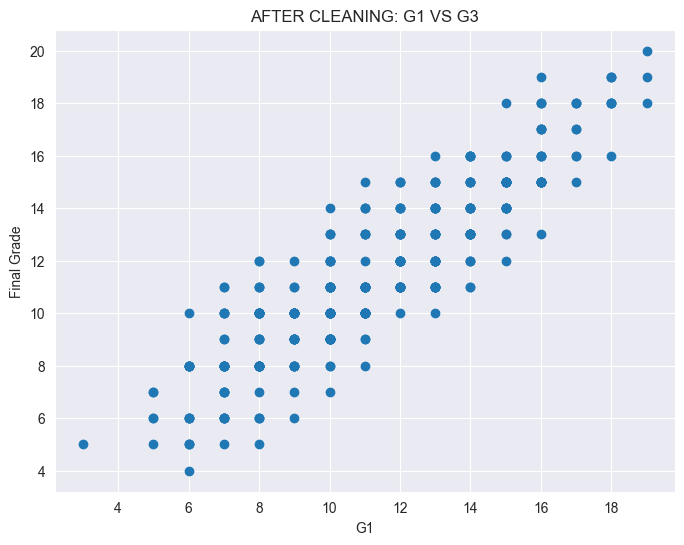

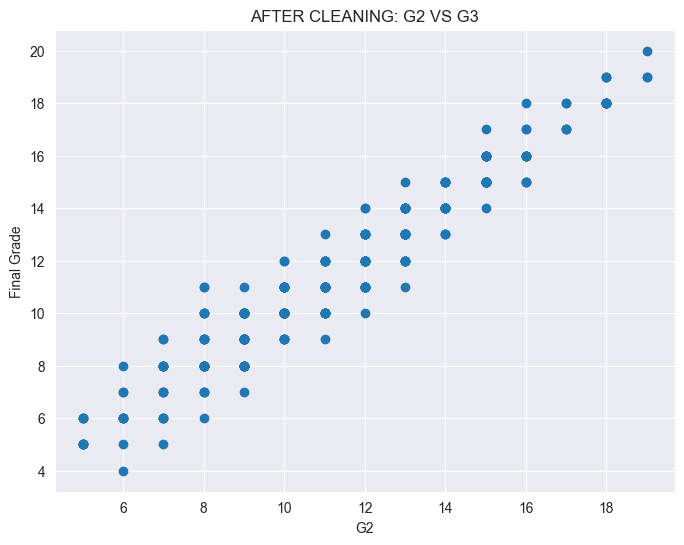

In [418]:
# First Grade and Second Grade AFTER CLEANING
pplot.figure(figsize=(8, 6))
pplot.scatter(data["G1"], data["G3"])
pplot.xlabel("G1")
pplot.ylabel("Final Grade")
pplot.title("AFTER CLEANING: G1 VS G3")

pplot.figure(figsize=(8, 6))
pplot.scatter(data["G2"], data["G3"])
pplot.xlabel("G2")
pplot.ylabel("Final Grade")
pplot.title("AFTER CLEANING: G2 VS G3")

In [419]:
lifestyle_cols = ['Dalc', 'Walc', 'health', 'goout', 'failures', 'studytime', 'freetime']

print(data[lifestyle_cols].dtypes)
print(data[lifestyle_cols].describe())
print(data[lifestyle_cols].info())

for col in lifestyle_cols:
    print(data[col].unique())
    print(data[col].value_counts().sort_index())

Dalc         int64
Walc         int64
health       int64
goout        int64
failures     int64
studytime    int64
freetime     int64
dtype: object
             Dalc        Walc      health       goout    failures   studytime  \
count  357.000000  357.000000  357.000000  357.000000  357.000000  357.000000   
mean     1.495798    2.330532    3.549020    3.098039    0.271709    2.042017   
std      0.919886    1.294974    1.402638    1.090779    0.671750    0.831895   
min      1.000000    1.000000    1.000000    1.000000    0.000000    1.000000   
25%      1.000000    1.000000    3.000000    2.000000    0.000000    1.000000   
50%      1.000000    2.000000    4.000000    3.000000    0.000000    2.000000   
75%      2.000000    3.000000    5.000000    4.000000    0.000000    2.000000   
max      5.000000    5.000000    5.000000    5.000000    3.000000    4.000000   

         freetime  
count  357.000000  
mean     3.246499  
std      1.011601  
min      1.000000  
25%      3.000000  
50%

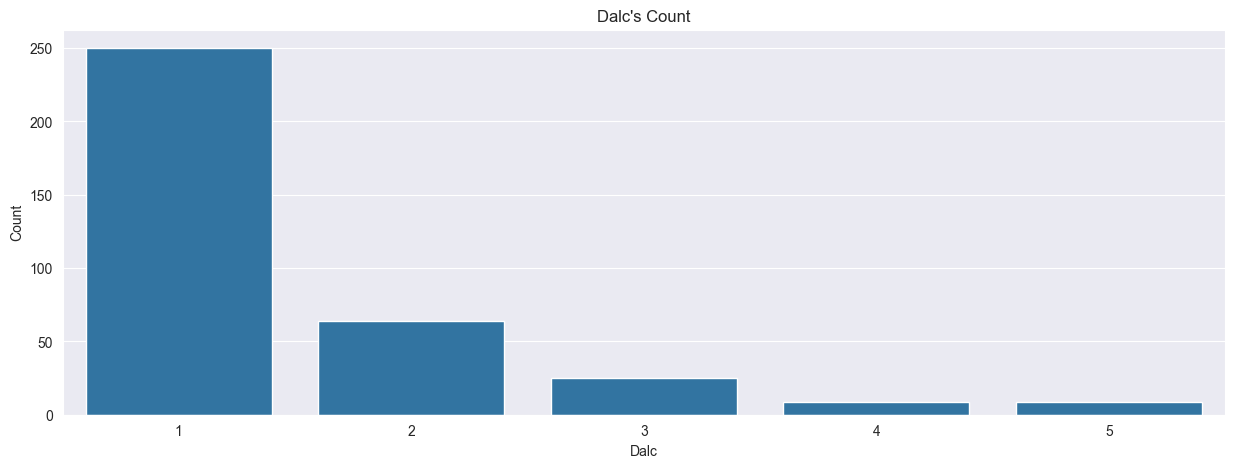

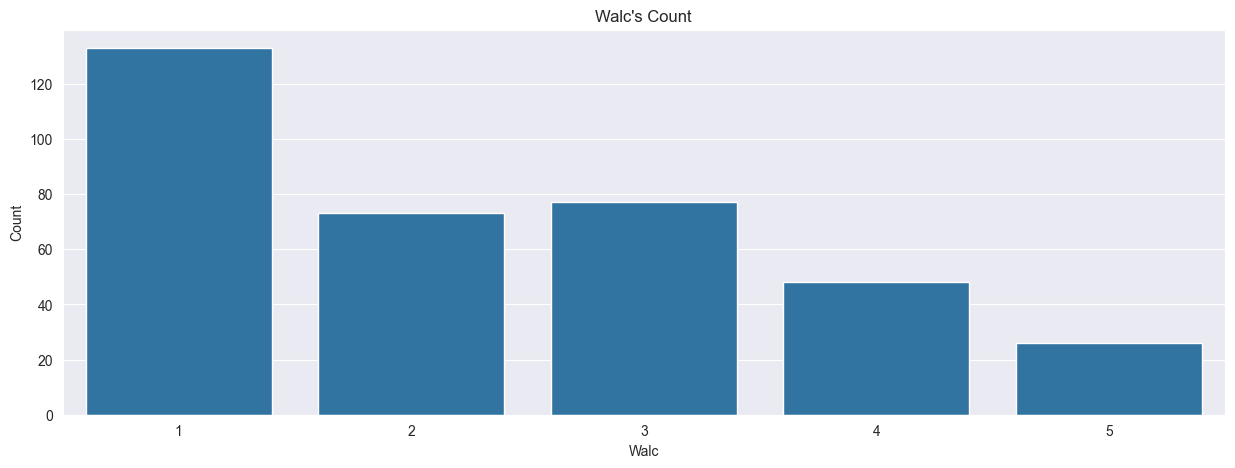

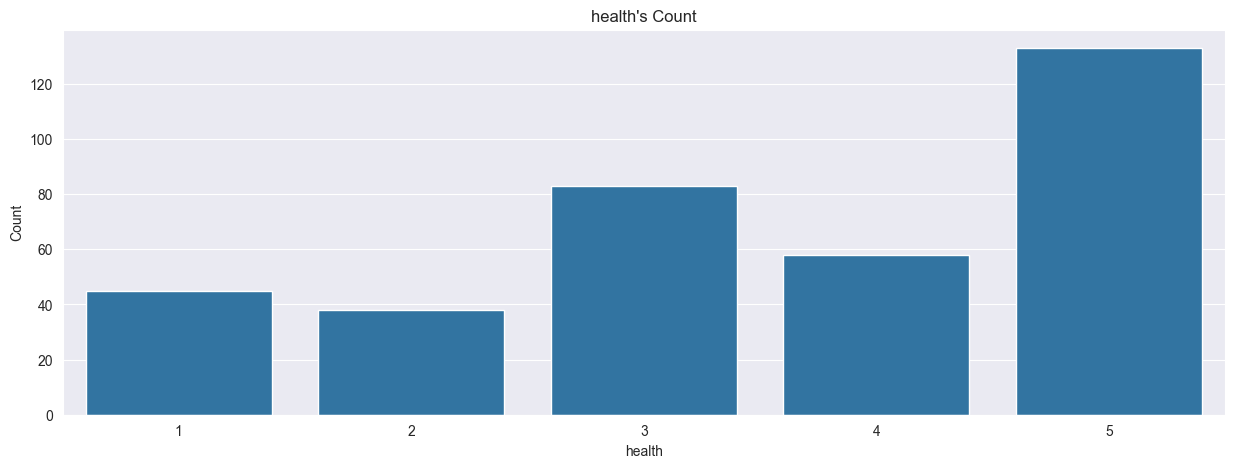

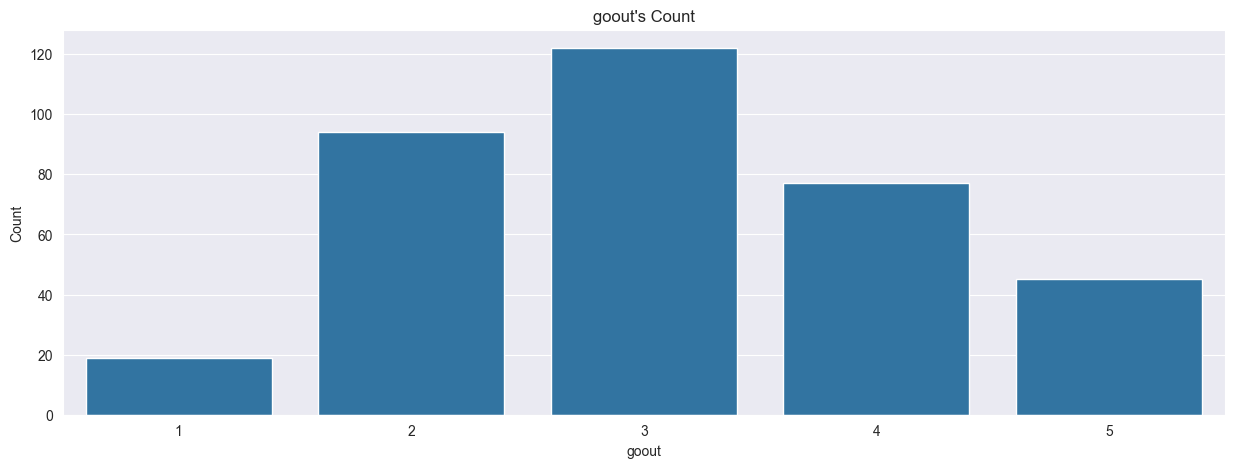

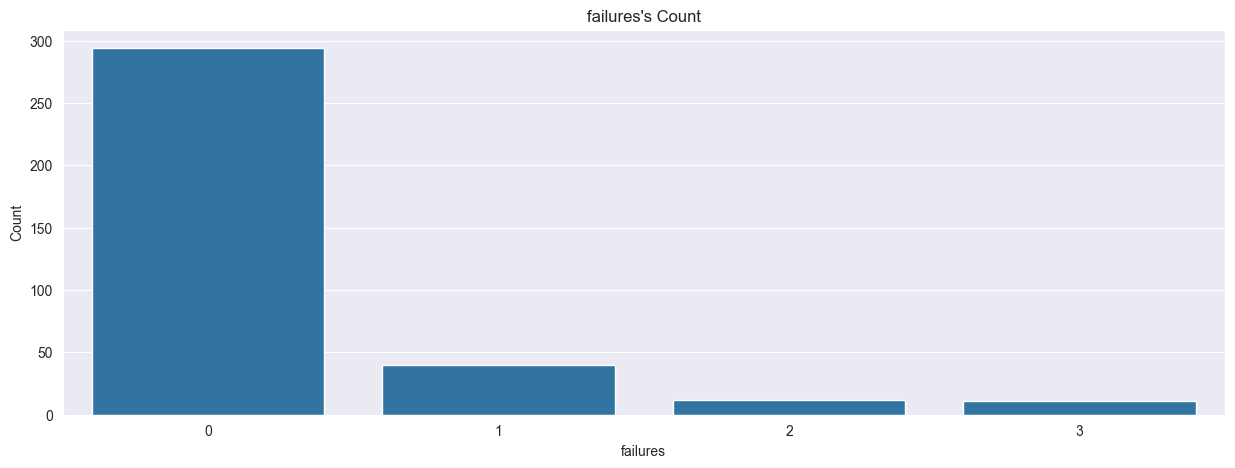

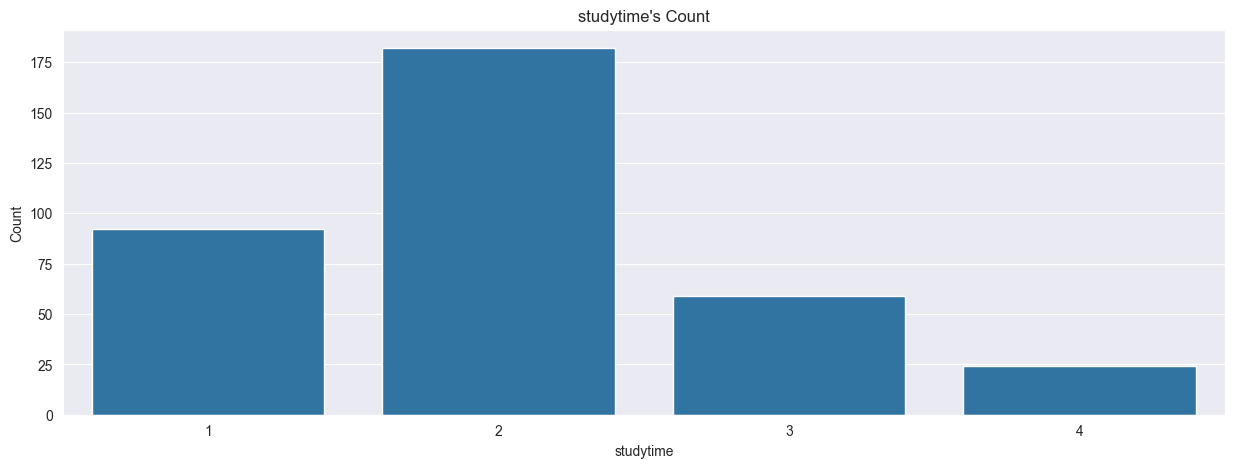

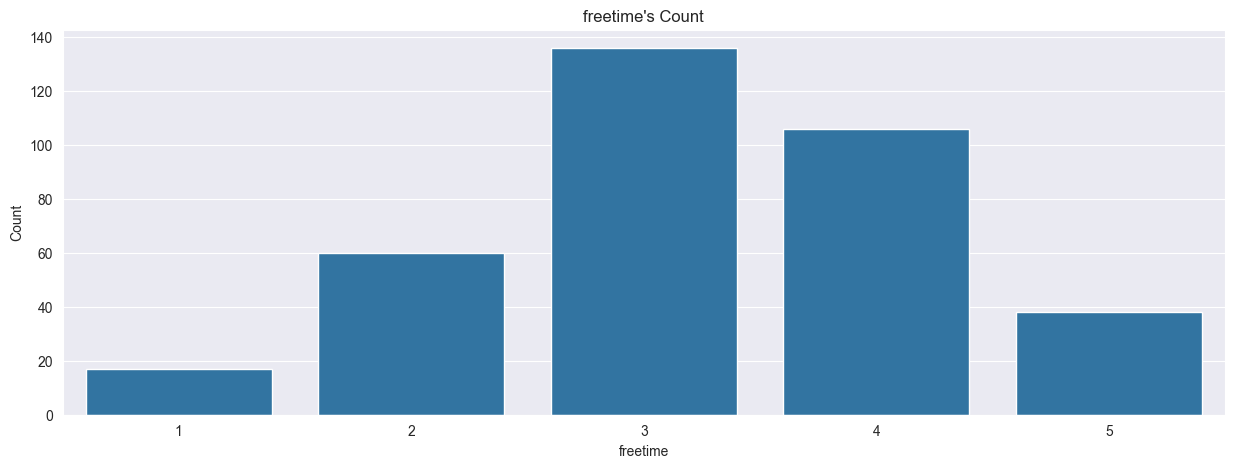

In [420]:
for col in lifestyle_cols:
    pplot.figure(figsize=(15, 5))
    sborn.countplot(x=data[col])
    pplot.xlabel(f"{col}")
    pplot.ylabel("Count")
    pplot.title(f"{col}'s Count")

In [421]:
print(data['absences'].describe())
print(data['absences'].value_counts().sort_index())

data = data[data['absences'] < 9]
print(data['absences'].value_counts().sort_index())

count    357.000000
mean       6.316527
std        8.187623
min        0.000000
25%        2.000000
50%        4.000000
75%        8.000000
max       75.000000
Name: absences, dtype: float64
absences
0     77
1      3
2     65
3      8
4     53
5      5
6     31
7      7
8     22
9      3
10    17
11     3
12    12
13     3
14    12
15     3
16     7
17     1
18     5
19     1
20     4
21     1
22     3
23     1
24     1
25     1
26     1
28     1
30     1
38     1
40     1
54     1
56     1
75     1
Name: count, dtype: int64
absences
0    77
1     3
2    65
3     8
4    53
5     5
6    31
7     7
8    22
Name: count, dtype: int64


In [422]:
bins = [0, 2, 4, 6, 8, float("inf")]
labels = ["0-1", "2-3", "4-5", "6-7", "8"]

data["absences"] = pd.cut(
    data["absences"],
    bins=bins,
    labels=labels,
    include_lowest=True
)

Text(0.5, 1.0, 'Grouped Absences Counts')

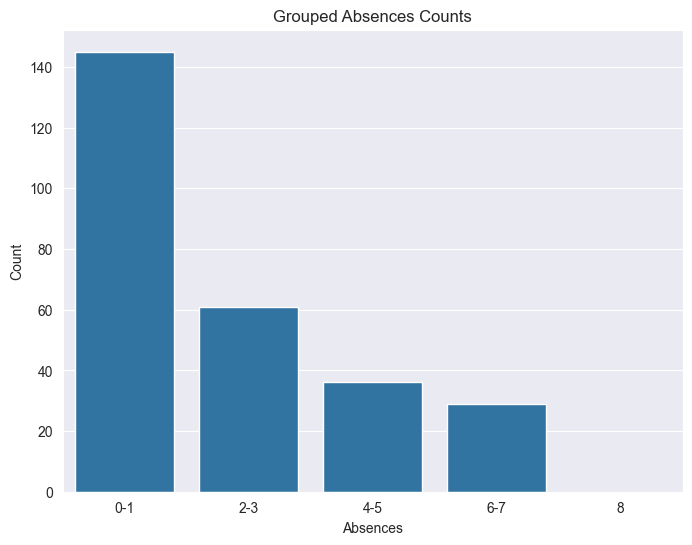

In [423]:
pplot.figure(figsize=(8, 6))
sborn.countplot(x=data['absences'], order=labels)
pplot.xlabel("Absences")
pplot.ylabel("Count")
pplot.title("Grouped Absences Counts")

int64
int64
int64


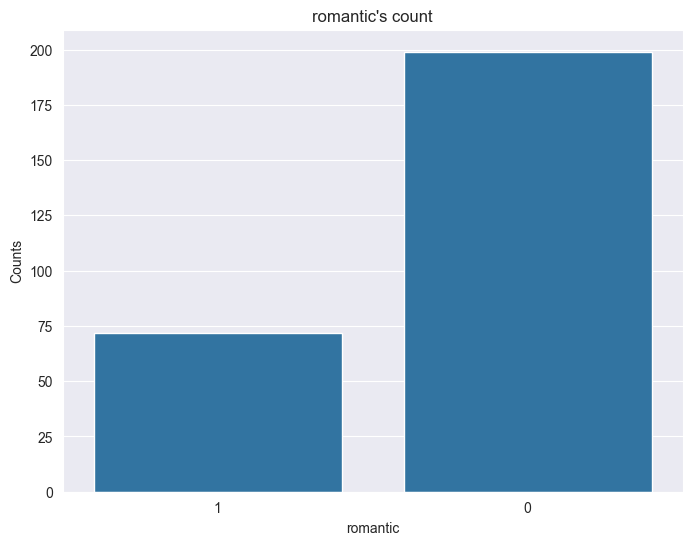

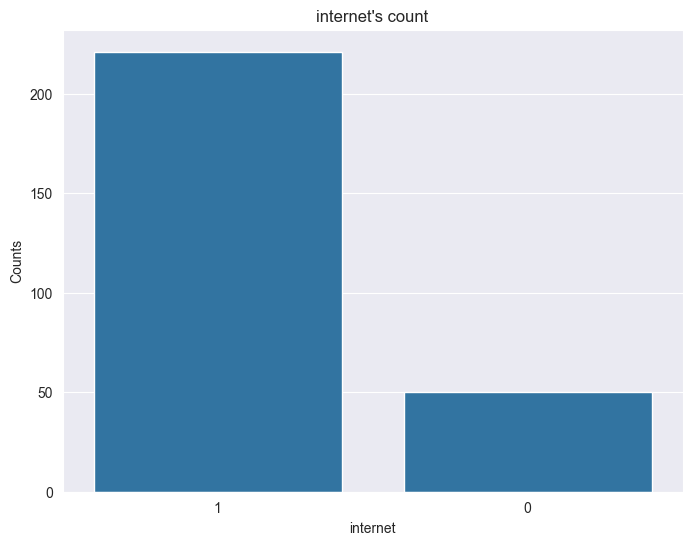

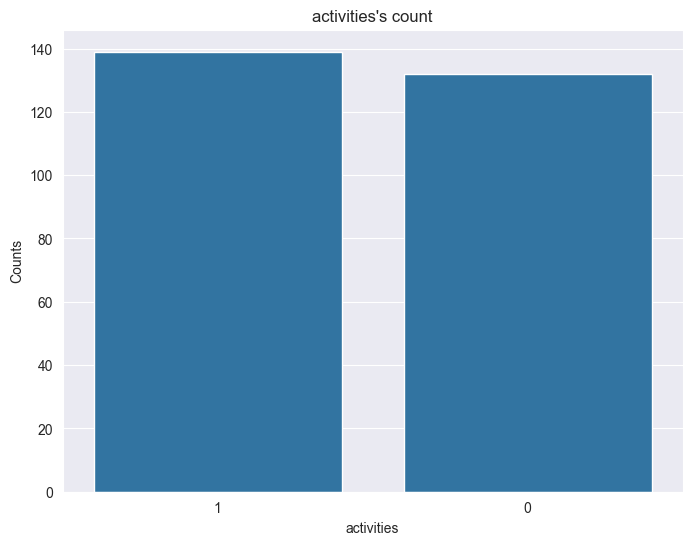

In [424]:
category_cols = ['romantic', 'internet', 'activities']
binary_features = [1, 0]
for col in category_cols:
    data[col] = data[col].map({"yes": 1, "no": 0})
    print(data[col].dtypes)

    pplot.figure(figsize=(8, 6))
    sborn.countplot(x=data[col], order=binary_features)
    pplot.xlabel(f"{col}")
    pplot.ylabel("Counts")
    pplot.title(f"{col}'s count")

In [425]:
features = [
    'G1', 'G2',
    'Dalc', 'Walc', 'health', 'goout', 'failures', 'studytime', 'freetime',
    'romantic', 'internet', 'activities'
]

X = data[features]
y = data['G3']

In [426]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [427]:
from sklearn.linear_model import LinearRegression

linear_model = LinearRegression()

linear_model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [428]:
y_pred = linear_model.predict(X_test)

In [429]:
from sklearn.metrics import (
    mean_absolute_error,
    root_mean_squared_error,
    r2_score
)

mae = mean_absolute_error(y_test, y_pred)
rmse = root_mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("RMSE:", rmse)
print("R2:", r2)

MAE: 0.6765674355716766
RMSE: 0.8559805562695452
R2: 0.9219678317859334


Text(0.5, 1.0, 'Actual vs. Predicted G3')

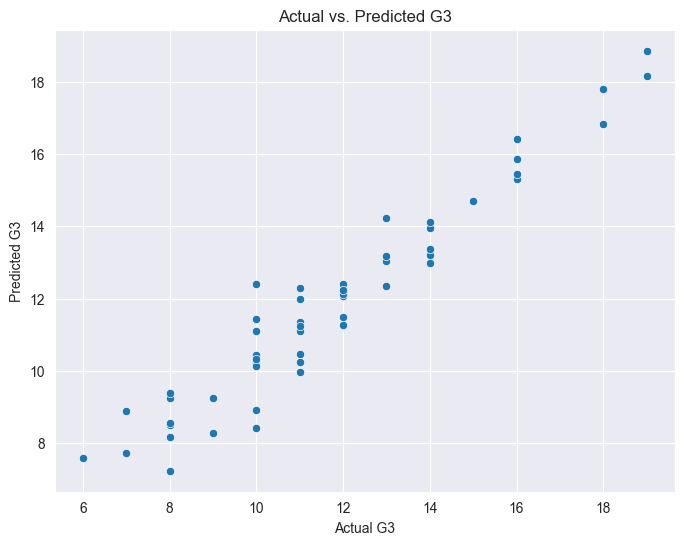

In [430]:
pplot.figure(figsize=(8, 6))
sborn.scatterplot(x=y_test, y=y_pred)
pplot.xlabel("Actual G3")
pplot.ylabel("Predicted G3")
pplot.title("Actual vs. Predicted G3")

In [431]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(n_estimators=100, random_state=42)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

In [432]:
mae = mean_absolute_error(y_test, rf_pred)
rmse = root_mean_squared_error(y_test, rf_pred)
r2 = r2_score(y_test, rf_pred)

print("MAE: ", mae)
print("RMSE: ", rmse)
print("R2: ", r2)

MAE:  0.7267272727272729
RMSE:  0.8970324814226477
R2:  0.9143036720180256
